### carico i dati ottenuti in precedenza del caso random

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
df = pd.read_pickle('D:/dataset_M1_M20_30_08_2026.pkl') # da questo seleziono solo le M dei casi random che voglio confrontare



records = []
yymmdd = '240813'
cell = 'cell0001'
spine_types = ['BLA', 'CA3']
main_matrix_ids = [] # ['M1', 'M2'] # , 'mm6', 'mm7']
ids = [1,2,3,8]
for i in ids:
    id = str(i)
    m_id = 'M' + id
    main_matrix_ids.append(m_id)

spine_types = ['BLA', 'CA3']
# main_matrix_ids = ['mm3'] # , 'mm4', 'mm5', 'mm6', 'mm7']

cond = ['random']
# spine_types
# main_matrix_ids
distances_sim = {}
ref_Vs = {}

n_Vm_per_assign = 50
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'random')
        ]

        data_values = aus_data['data'].to_numpy()

        # lista con i 21 ref_V. Ho 21 riassegnazioni di BLA e CA3. Prendo come rifrimento il primo Vm di output ottenuto applicando la prima matrice di input alla prima riassegnazione delle spine, prima di fare le permutazioni delle righe della matrice
        ref_Vs[(SpineType, mm, 'random')] = []

        # lista di tutte le distanze
        aus_distances = []

        # 21 gruppi (che corrispondono alle 21 riassegnazioni delle spine) da 50 file (50 permutazioni della matrice di input per ogni riassegnazione delle spine)
        for i in range(0, len(data_values), n_Vm_per_assign):

            # primo file di ogni gruppo = ref_V
            ref_V = data_values[i]

            ref_Vs[(SpineType, mm, 'random')].append(ref_V)

            # i successivi 49 file vengono confrontati con questo ref_V
            for k in data_values[i + 1:i + n_Vm_per_assign]:

                aus_d = np.sqrt(np.sum((k - ref_V) ** 2))
                aus_distances.append(aus_d)

        distances_sim[(SpineType, mm, 'random')] = aus_distances


In [20]:
# carico i dati per experiment in cui ho fatto 1000 permutazioni

records = []
yymmdd = '240813'
cell = 'cell0001'
spine_types = ['BLA', 'CA3']

date_str = '30_08_2026'

for main_matrix_id in main_matrix_ids:      # nuovo loop esterno

    for spine_type in spine_types:

        # --- experiment ---
        data_path_exp = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}_experiment_v2" / "output_soma_v"
        for file in sorted(data_path_exp.glob("*.npy")):

            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "experiment",
                "filename": file.name,
                "data": np.load(file),
                "path": file,
            })
        '''

        # --- random ---
        data_path_rnd = Path('D:/') / f"{yymmdd}_{cell}_{spine_type}_{main_matrix_id}_{date_str}" / "output_soma_v"
        for file in sorted(data_path_rnd.glob("*.npy")):
            if file.name.startswith("._"):
                continue
            records.append({
                "main_matrix_id": main_matrix_id,
                "date_str": date_str,
                "spine_type": spine_type,
                "condition": "random",
                "filename": file.name,
                "data": np.load(file, allow_pickle=True),
                "path": file,
            })
        '''
df_exp_2 = pd.DataFrame(records)


In [21]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df_exp_2.loc[
            (df_exp_2["spine_type"] == SpineType) &
            (df_exp_2["main_matrix_id"] == mm) &
            (df_exp_2["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp[(SpineType, mm, 'experiment')] = aus_distances


In [25]:
spine_types = ['BLA', 'CA3']
#main_matrix_ids = ['mm3', 'mm4', 'mm5', 'mm6', 'mm7']
# main_matrix_ids = ['M1', 'M2']
cond = ['experiment']
# spine_types
# main_matrix_ids
distances_exp_1 = {}
ref_Vs = {}
for mm in main_matrix_ids:
    for SpineType in spine_types:
        aus_data = df.loc[
            (df["spine_type"] == SpineType) &
            (df["main_matrix_id"] == mm) &
            (df["condition"] == 'experiment')
        ]
        ref_V = aus_data['data'].iloc[0] # il riferimento e' il Vm ottenuto applicando la main_matrix di input di ogni gruppo di mm
        ref_Vs[SpineType,mm,'experiment'] = ref_V
        aus_distances = []
        for k in aus_data['data'][1:]: # qui va bene perche' escludo il primo set di Vm che e' quello di riferimento, altrimenti la differenza tra Vm e se stesso viene 0
            aus_d = np.sqrt(np.sum((k - ref_V)**2))
            aus_distances.append(aus_d)
        distances_exp_1[(SpineType, mm, 'experiment')] = aus_distances


In [22]:
len(distances_exp['BLA', 'M1' , 'experiment'])

999

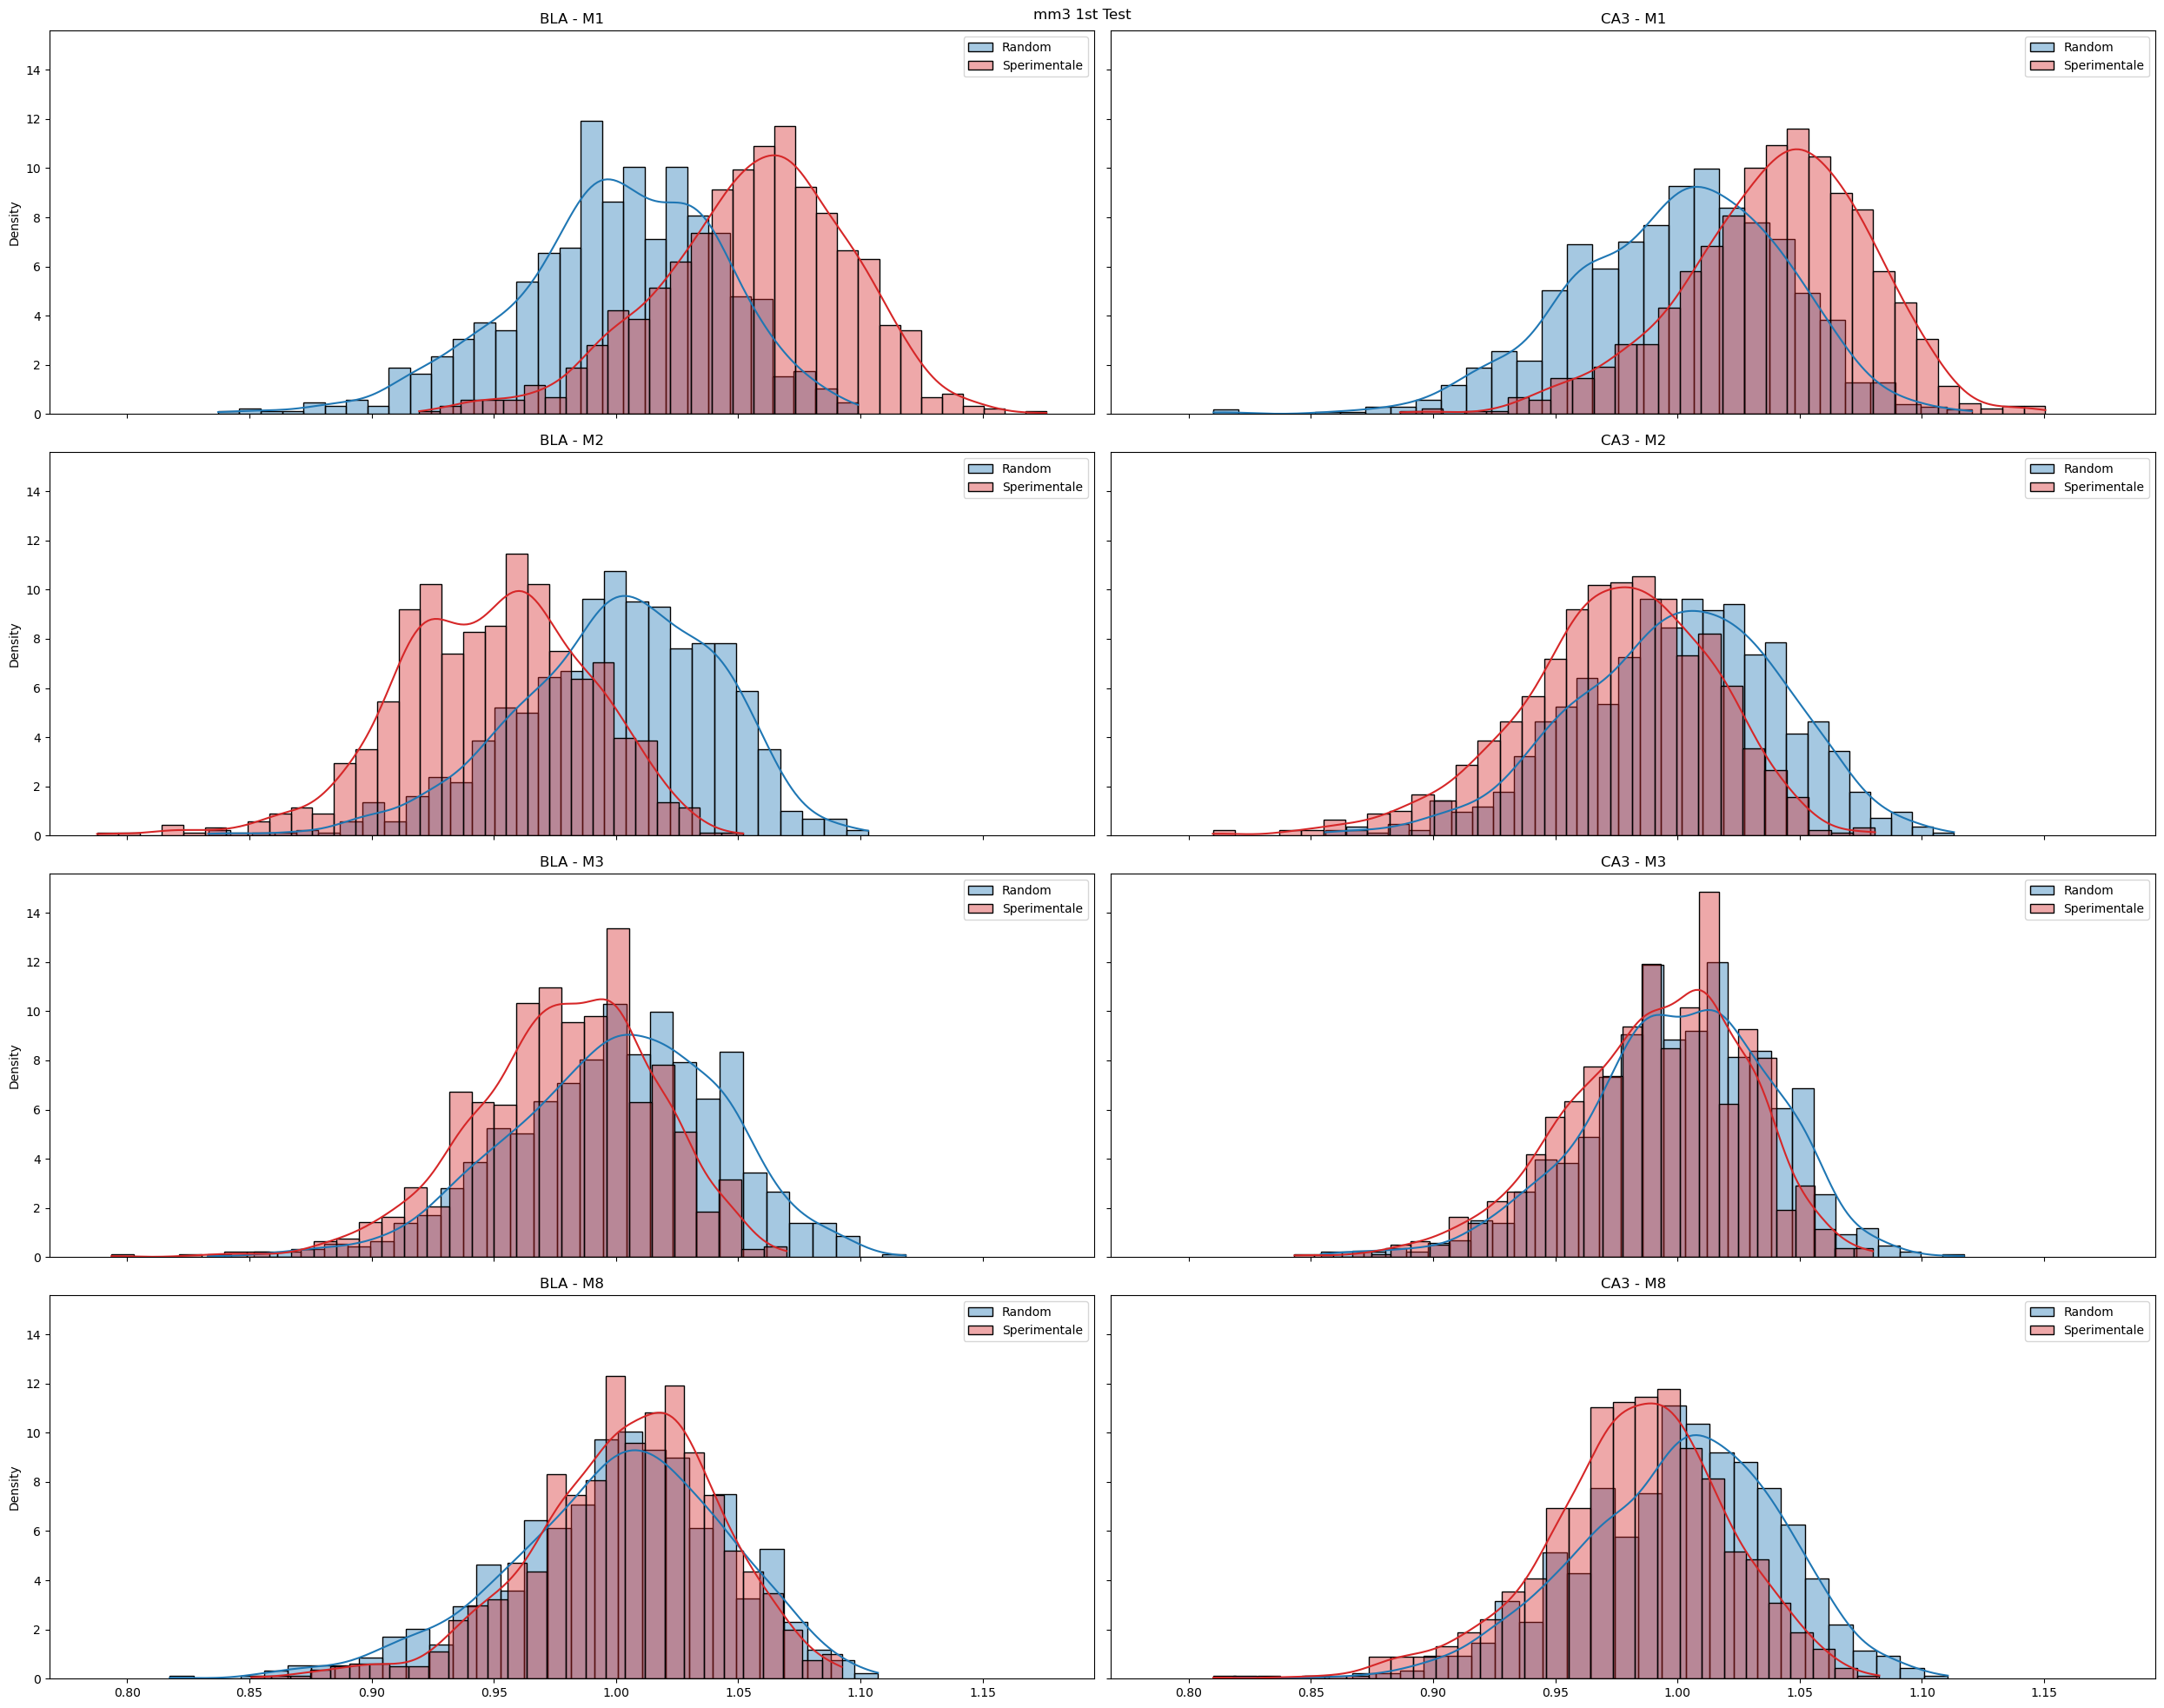

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
# mms = ['mm3'] # , 'mm4', 'mm5','mm6','mm7']
regions = ['BLA', 'CA3']
mms = main_matrix_ids
fig, axes = plt.subplots(
    len(mms), 2,
    figsize=(25, 20),
    sharex=True,
    sharey=True
)
fig.suptitle('mm3 1st Test')
for i, mm in enumerate(mms):
    for j, region in enumerate(regions):

        ax = axes[i,j]

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )

        # dati sperimentali
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )

            # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        d_exp = exp_data / mu
        sns.histplot(
            d_sim,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Random',
            color='tab:blue',
            ax=ax
        )
        sns.histplot(
            d_exp,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Sperimentale',
            color='tab:red',
            ax=ax
        )
        ax.legend()
        ax.set_title(f'{region} - {mm}')

#plt.xlim([0.75, 1.15])
#plt.ylim([0, 40])

plt.tight_layout()
plt.show()

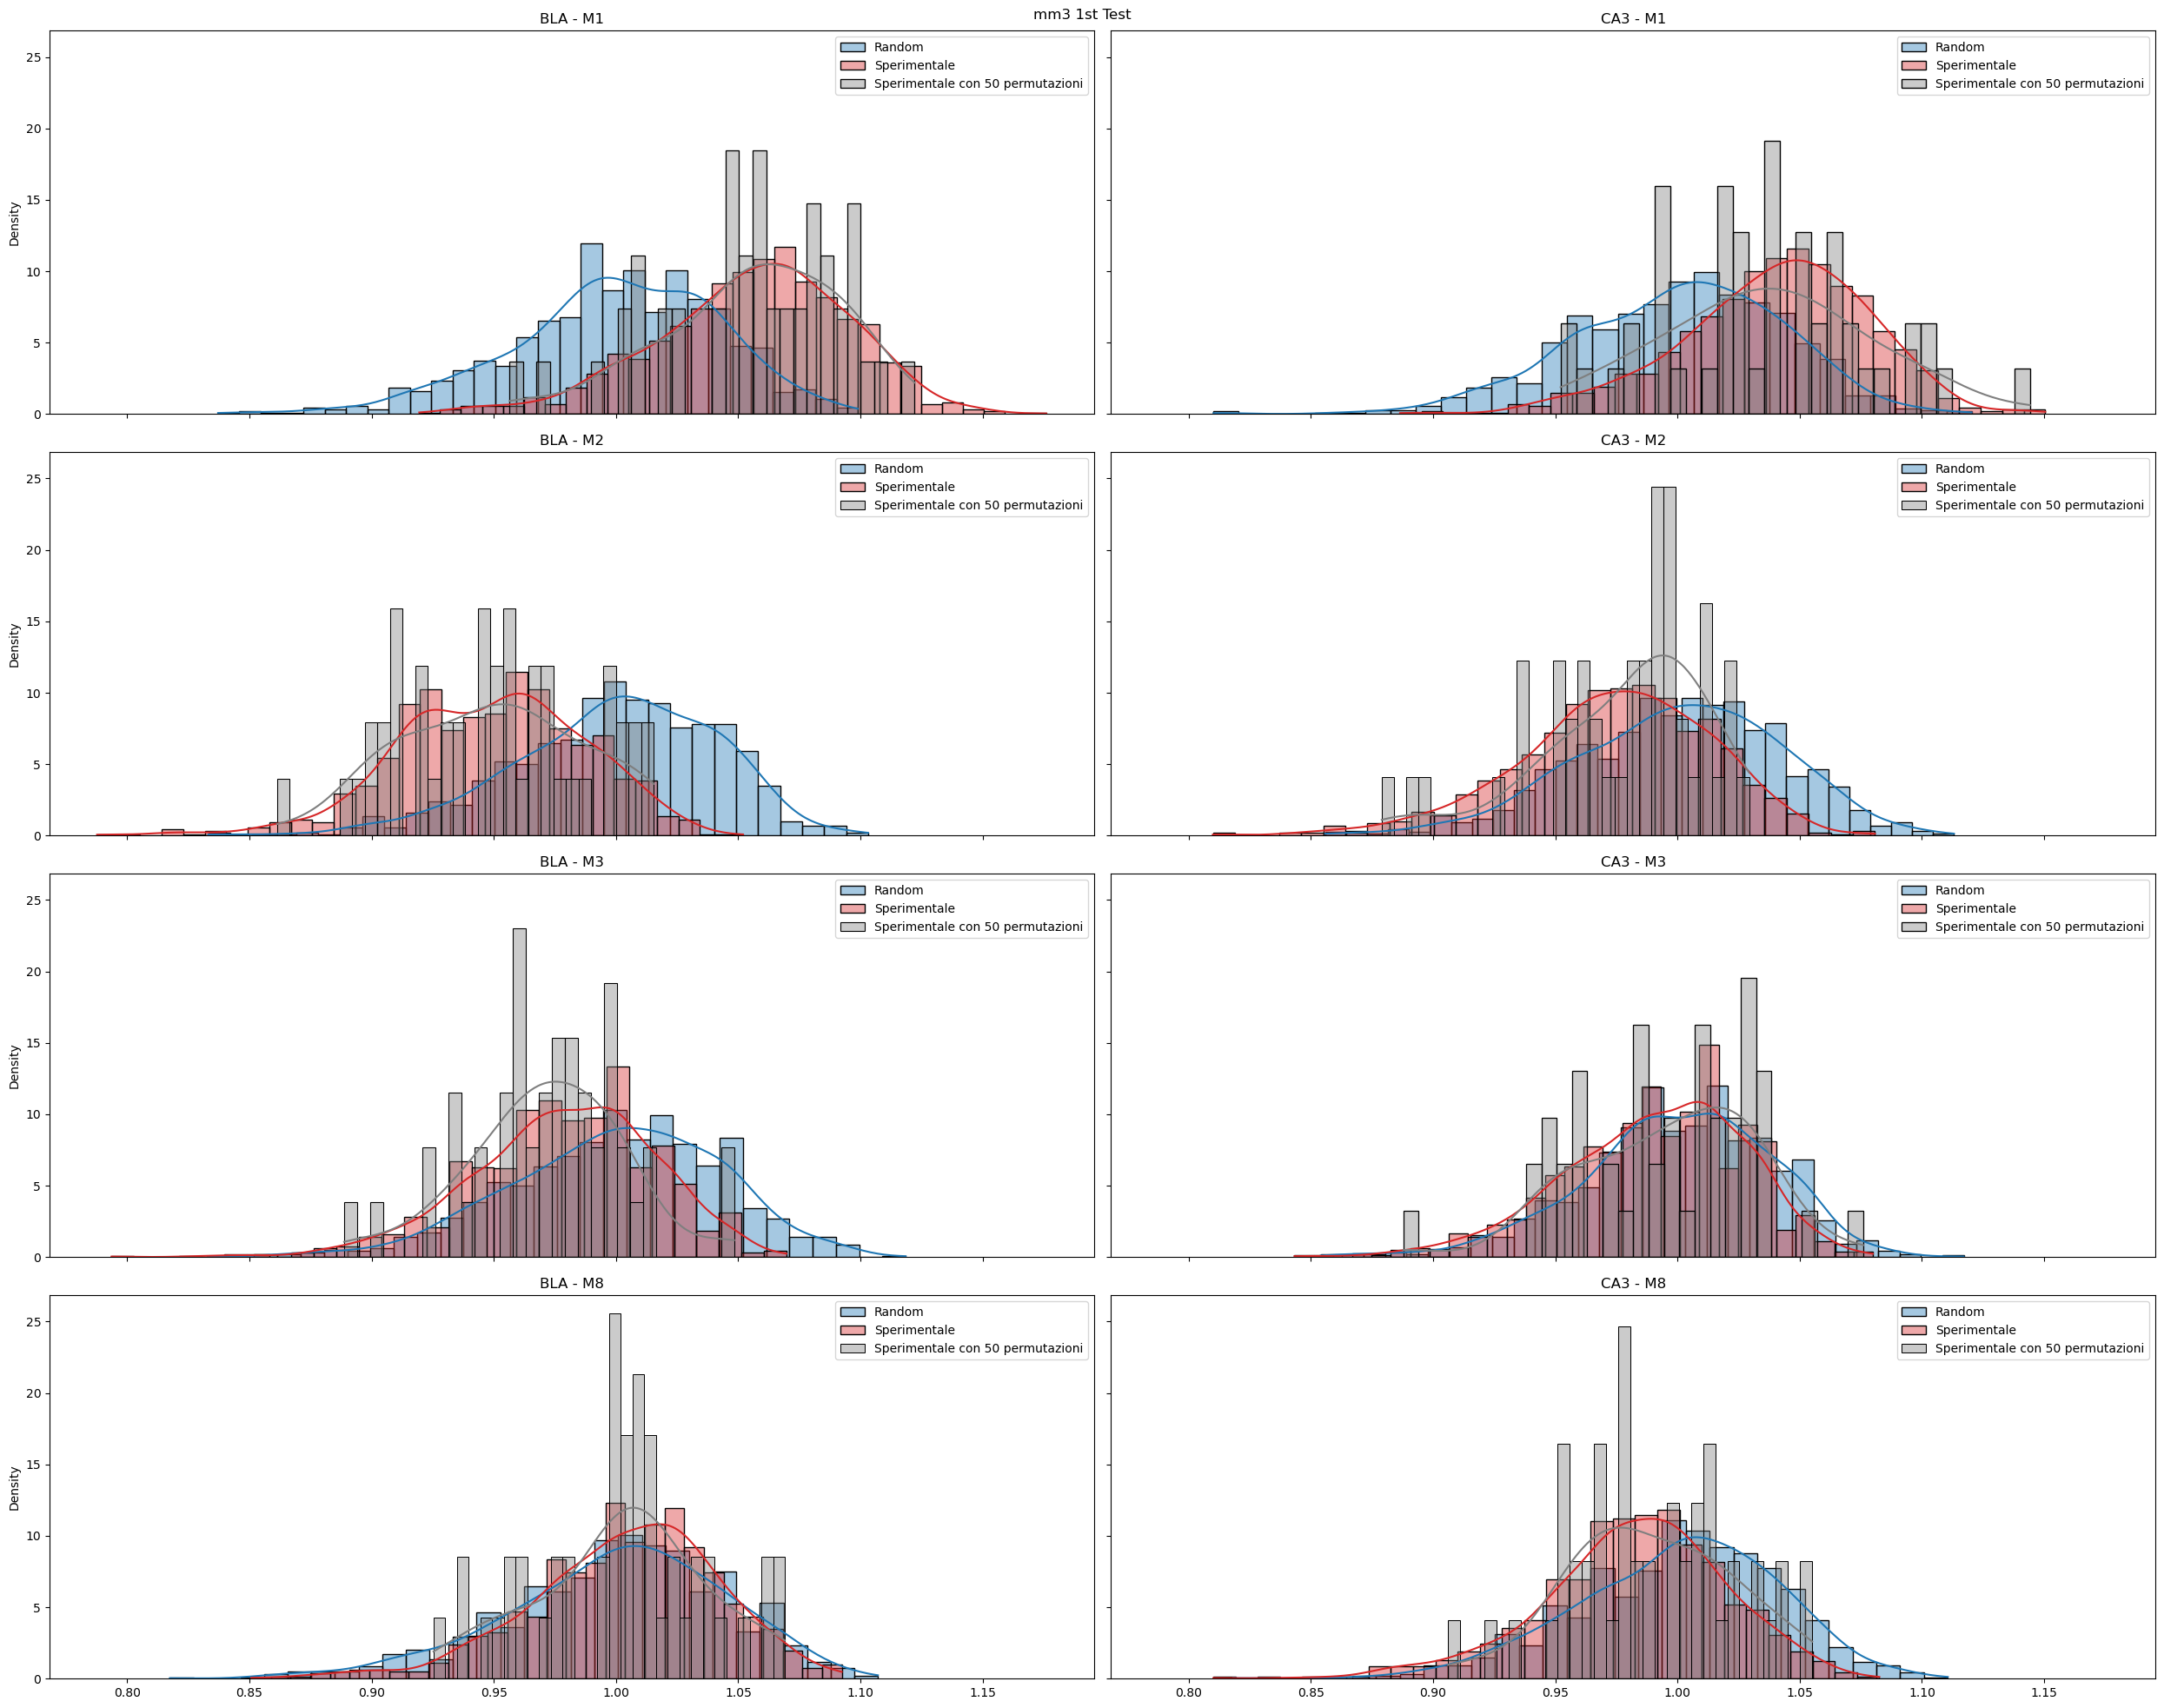

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
# mms = ['mm3'] # , 'mm4', 'mm5','mm6','mm7']
regions = ['BLA', 'CA3']
mms = main_matrix_ids
fig, axes = plt.subplots(
    len(mms), 2,
    figsize=(25, 20),
    sharex=True,
    sharey=True
)
fig.suptitle('mm3 1st Test')
for i, mm in enumerate(mms):
    for j, region in enumerate(regions):

        ax = axes[i,j]

        random_data = np.array(
            distances_sim[region, mm, 'random']
        )

        # dati sperimentali
        exp_data = np.array(
            distances_exp[region, mm, 'experiment']
        )
        exp_data_1 = np.array(
            distances_exp_1[region, mm, 'experiment']
        )

            # media random
        mu = np.mean(random_data)

        # normalizzazione
        d_sim = random_data / mu
        d_exp = exp_data / mu
        d_exp_1 = exp_data_1/ mu
        sns.histplot(
            d_sim,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Random',
            color='tab:blue',
            ax=ax
        )
        sns.histplot(
            d_exp,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Sperimentale',
            color='tab:red',
            ax=ax
        )
        sns.histplot(
            d_exp_1,
            kde=True,
            stat='density',
            bins=30,
            alpha=0.4,
            label='Sperimentale con 50 permutazioni',
            color='tab:gray',
            ax=ax
        )
        ax.legend()
        ax.set_title(f'{region} - {mm}')

#plt.xlim([0.75, 1.15])
#plt.ylim([0, 40])

plt.tight_layout()
plt.show()